## 1. Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)

## 2. Load the data

In [2]:
data_dir = "/kaggle/input/datasets/mdnahidurrahmankh/bangladesh-road-accident-dataset-2007-2024"

candidates = []
for folder, _, files in os.walk(data_dir):
    for name in files:
        if name.lower().endswith((".csv", ".xlsx", ".xls")):
            candidates.append(os.path.join(folder, name))

preferred = [path for path in candidates if "accident" in os.path.basename(path).lower()]
file_path = sorted(preferred or candidates)[0]
print("Reading:", file_path)

if file_path.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_path)
else:
    df = pd.read_csv(file_path, encoding="utf-8", encoding_errors="replace")

print(df.shape)
df.head()

Reading: /kaggle/input/datasets/mdnahidurrahmankh/bangladesh-road-accident-dataset-2007-2024/Accident_Dataset final/Modified_Accident_Dataset final.xlsx
(47680, 31)


,Accident Serial No,Date,Time,Location,Longitude and Latitude,Driver Age,Accident Narrative,Vehicle Info,Vehicle Count,Death Count,Death Info,Injury Count,Injury Info,Light Condition,Weather_x,Road Surface Type,Road nature,Road classification,Place characteristic,Type of Road connection point,Road Surface Condition,Victim Category,Trafic Condition,ID,Year,Month,Accident_Intensity,Junction,Traffic_Control,Weather_y,Lighting
0,377,2022-06-05 00:00:00,06.35 am,Dhaka Regional Airport road (near the City Gat...,23.84278° N/90.40056° E,26,"At around 11:45 AM, a fully loaded cargo truck...",Car - Pedestrian collision,2,0,"Mr. Saiful Islam 50 years old, resident of Sa...",0,"Mr. Saiful Islam 50 years old, resident of Sa...",Dusk,Rainy,Paved,Lane,City Road,Urban,T-Junction,Dry,Pedestrian,Police determined,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
1,378,2022-03-06 00:00:00,08:20 AM,Mirpur-11 Road near Pallabi Bridge,23.80610° N/90.36690° E,26,A motorcycle collided with a bicycle due to su...,Motorcycle-bicycle collision,2,2,"Mr. Saiful Islam 50 years old, resident of Sa...",0,Motorcyclist: minor head injuries; Cyclist: mi...,Day,Sunny,Paved,Lane,City Road,Urban,T-Junction,Wet,Motorcyclist,Speeding,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
2,379,2022-12-02 00:00:00,07:30 AM,Old Airport Road near Uttara Sector-6,23.86500° N/90.40000° E,26,"A car collided with a scooter at the junction,...",Car-scooter collision,2,0,"Mr. Saiful Islam 50 years old, resident of Sa...",0,Scooter rider: broken arm,Night,Foggy,Paved,Lane,City Road,Urban,T-Junction,Wet,Scooter rider,Right-of-way violation,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
3,380,13/6/2022,02:15 PM,Mirpur DOHS Road near BNS Center,23.81200° N/90.36500° E,26,A motorcycle collided with a speeding car; the...,Motorcycle - Car collision,2,0,"Mr. Saiful Islam 50 years old, resident of Sa...",1,Rider: critical head trauma,Dusk,Sunny,Paved,Lane,Regional Road,Urban,T-Junction,Dry,Motorcyclist,Speeding,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk
4,381,14/6/2022,09:00 PM,Banani Circle-2 Intersection,23.78700° N/90.41700° E,26,A pedestrian was struck while crossing at a ma...,Vehicle - Pedestrian collision,1,1,"Mr. Saiful Islam 50 years old, resident of Sa...",3,Pedestrian: leg fractures,Night,Sunny,Paved,Lane,City Road,Urban,T-Junction,Good,Pedestrian,Distraction,906,2007,September,Death,3-Way/ T junction,Uncontrolled,Sunny,Dusk


## 3. Cleaning and data quality

In [3]:
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

is_numeric = pd.api.types.is_numeric_dtype

for column in df.columns:
    if not is_numeric(df[column]):
        df[column] = df[column].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan, "": np.nan})

rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {rows_before - len(df)}")
print(f"Shape after cleaning: {df.shape}")
df.info()

Duplicate rows removed: 4
Shape after cleaning: (47676, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47676 entries, 0 to 47675
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   accident_serial_no             47676 non-null  int64 
 1   date                           47676 non-null  object
 2   time                           47676 non-null  object
 3   location                       47676 non-null  object
 4   longitude_and_latitude         47676 non-null  object
 5   driver_age                     47676 non-null  int64 
 6   accident_narrative             47676 non-null  object
 7   vehicle_info                   47676 non-null  object
 8   vehicle_count                  47676 non-null  int64 
 9   death_count                    47676 non-null  int64 
 10  death_info                     47676 non-null  object
 11  injury_count                   47676 non-null  int64 
 12  

In [4]:
missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found")
else:
    ax = missing.sort_values().plot(kind="barh", color="indianred")
    ax.set_title("Missing values by column (%)")
    ax.set_xlabel("Percent missing")
    plt.tight_layout()
    plt.show()

No missing values found


## 4. Preparing the analysis columns

The notebook finds the date, time, casualty and location columns by name and builds calendar features from them. Each accident is then classified into a **severity class**, and a binary **severe accident** flag is created for comparing groups.

In [5]:
def find_column(keywords, exclude=()):
    for keyword in keywords:
        for column in df.columns:
            if keyword in column and column not in exclude:
                return column
    return None


date_col = find_column(["date"])
year_col = find_column(["year"], exclude=[date_col])
time_col = find_column(["time", "hour"], exclude=[date_col])
killed_col = find_column(["killed", "death", "dead", "fatal"])
injured_col = find_column(["injur"])
district_col = find_column(["district"])
division_col = find_column(["division"])

detected = {
    "date": date_col,
    "year": year_col,
    "time": time_col,
    "killed": killed_col,
    "injured": injured_col,
    "district": district_col,
    "division": division_col,
}
pd.Series(detected, name="detected column").to_frame()

,detected column
date,date
year,year
time,time
killed,death_count
injured,injury_count
district,None
division,None


In [6]:
season_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Summer", 4: "Summer", 5: "Summer",
              6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon", 10: "Autumn", 11: "Autumn"}

if date_col is not None:
    parsed_date = pd.to_datetime(df[date_col], errors="coerce")
    if parsed_date.notna().mean() > 0.5:
        df["year"] = parsed_date.dt.year
        df["month"] = parsed_date.dt.month
        df["weekday"] = parsed_date.dt.day_name()
        df["season"] = parsed_date.dt.month.map(season_map)

if "year" not in df.columns and year_col is not None:
    df["year"] = pd.to_numeric(df[year_col], errors="coerce")

if time_col is not None:
    if is_numeric(df[time_col]):
        hours = df[time_col]
    else:
        hours = pd.to_datetime(df[time_col].astype(str), errors="coerce").dt.hour
    if hours.notna().mean() > 0.5 and hours.dropna().between(0, 23).all():
        df["hour"] = hours
        df["day_part"] = pd.cut(df["hour"], bins=[-1, 5, 11, 17, 23],
                                labels=["Night", "Morning", "Afternoon", "Evening"]).astype(object)

engineered = [column for column in ["year", "month", "weekday", "season", "hour", "day_part"] if column in df.columns]
print("Calendar features created:", engineered)

Calendar features created: ['year', 'month', 'hour', 'day_part']


In [7]:
count_col = killed_col if killed_col is not None else injured_col
if count_col is None:
    raise ValueError("No casualty column was found. Check the column names printed in the previous cells.")

casualty_cols = [column for column in [killed_col, injured_col] if column is not None]
for column in casualty_cols:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna(subset=[count_col]).reset_index(drop=True)
df["total_casualties"] = df[casualty_cols].fillna(0).sum(axis=1)

positive_share = (df[count_col] > 0).mean()
if 0.1 <= positive_share <= 0.9:
    severity_threshold = 0
else:
    levels = np.unique(df[count_col])
    shares = pd.Series({level: (df[count_col] > level).mean() for level in levels})
    shares = shares[shares > 0]
    severity_threshold = (shares - 0.3).abs().idxmin() if not shares.empty else 0

df["severe"] = (df[count_col] > severity_threshold).astype(int)

severity_order = ["0", "1", "2-4", "5+"]
df["severity_class"] = pd.cut(df[count_col], bins=[-1, 0, 1, 4, np.inf], labels=severity_order).astype(object)

print(f"Casualty measure: {count_col}")
print(f"Severe accident = {count_col} greater than {severity_threshold}")
print(f"Severe share: {df['severe'].mean():.1%}")

Casualty measure: death_count
Severe accident = death_count greater than 0
Severe share: 66.8%


## 5. Severity classification

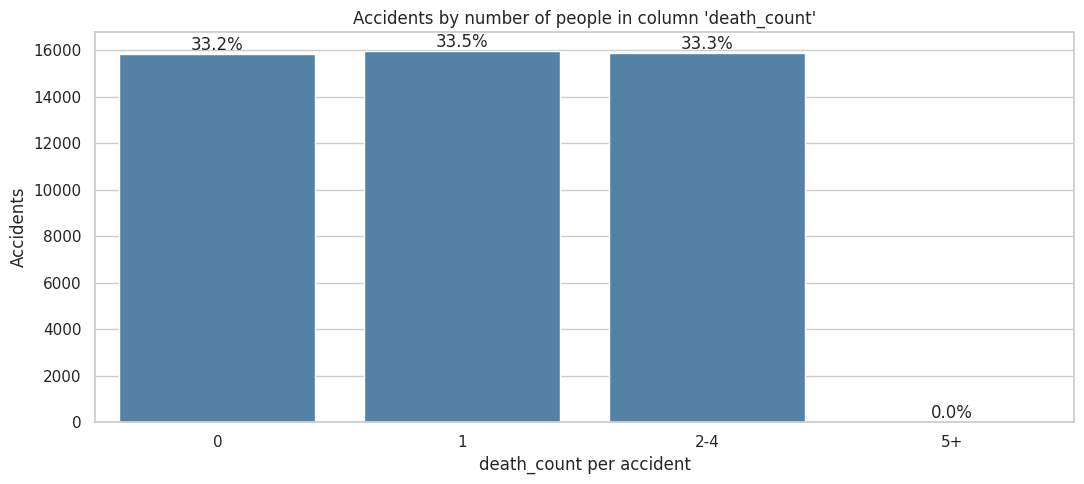

In [8]:
class_counts = df["severity_class"].value_counts().reindex(severity_order).fillna(0)
class_share = class_counts / class_counts.sum() * 100

ax = sns.barplot(x=class_counts.index, y=class_counts.values, color="steelblue")
for position, (count, share) in enumerate(zip(class_counts.values, class_share.values)):
    ax.text(position, count, f"{share:.1f}%", ha="center", va="bottom")
ax.set_title(f"Accidents by number of people in column '{count_col}'")
ax.set_xlabel(f"{count_col} per accident")
ax.set_ylabel("Accidents")
plt.tight_layout()
plt.show()

## 6. Trends over the years

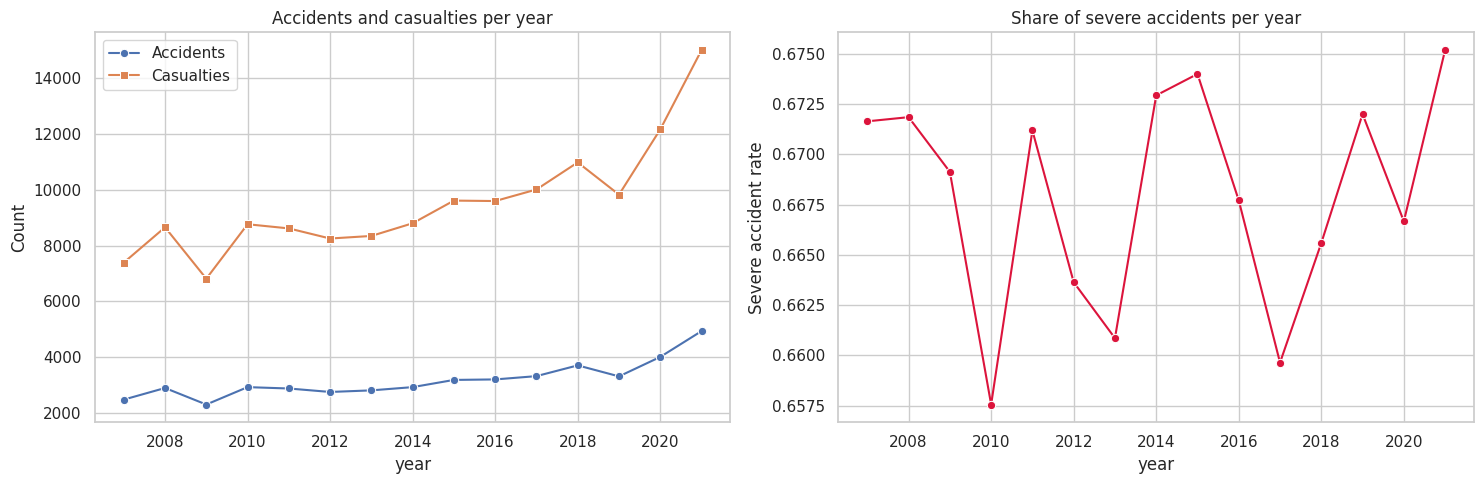

Average change: +123.6 accidents per year
2007 to 2021: +98.8% in recorded accidents


In [9]:
yearly = pd.DataFrame()

if "year" in df.columns:
    yearly = df.dropna(subset=["year"]).groupby("year").agg(
        accidents=("severe", "size"),
        casualties=("total_casualties", "sum"),
        severe_rate=("severe", "mean"),
    ).reset_index()
    yearly["year"] = yearly["year"].astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.lineplot(data=yearly, x="year", y="accidents", marker="o", ax=axes[0], label="Accidents")
    sns.lineplot(data=yearly, x="year", y="casualties", marker="s", ax=axes[0], label="Casualties")
    axes[0].set_title("Accidents and casualties per year")
    axes[0].set_ylabel("Count")
    sns.lineplot(data=yearly, x="year", y="severe_rate", marker="o", color="crimson", ax=axes[1])
    axes[1].set_title("Share of severe accidents per year")
    axes[1].set_ylabel("Severe accident rate")
    plt.tight_layout()
    plt.show()

    if len(yearly) >= 3:
        slope = np.polyfit(yearly["year"], yearly["accidents"], 1)[0]
        first, last = yearly.iloc[0], yearly.iloc[-1]
        change = (last["accidents"] - first["accidents"]) / first["accidents"] * 100
        print(f"Average change: {slope:+.1f} accidents per year")
        print(f"{int(first['year'])} to {int(last['year'])}: {change:+.1f}% in recorded accidents")

## 7. When accidents happen

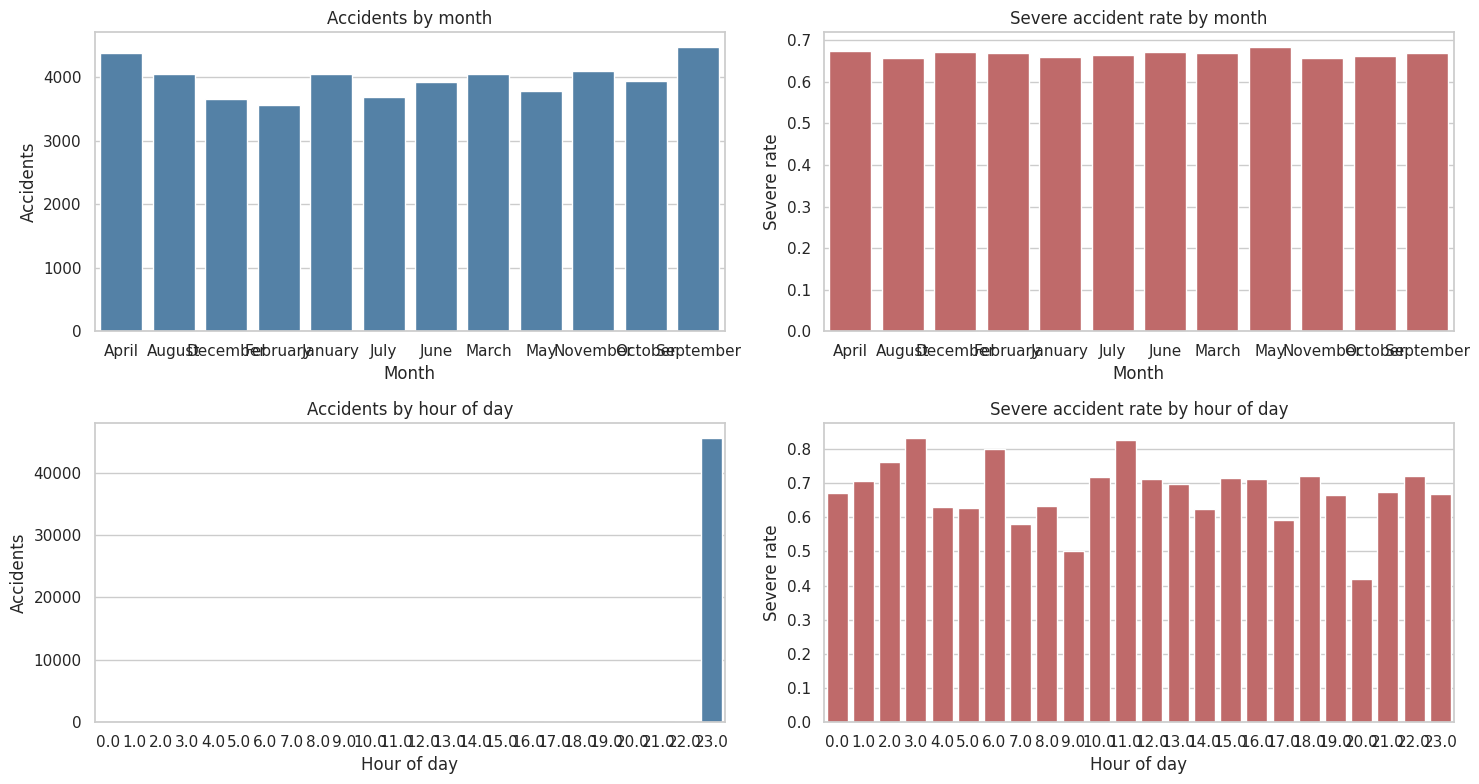

In [10]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
temporal = [("month", "Month"), ("weekday", "Day of week"), ("hour", "Hour of day"), ("season", "Season")]
available = [item for item in temporal if item[0] in df.columns]

if available:
    fig, axes = plt.subplots(len(available), 2, figsize=(15, 4 * len(available)), squeeze=False)
    for row, (column, label) in zip(axes, available):
        summary = df.groupby(column).agg(accidents=("severe", "size"), severe_rate=("severe", "mean"))
        if column == "weekday":
            summary = summary.reindex([day for day in day_order if day in summary.index])
        sns.barplot(x=summary.index.astype(str), y=summary["accidents"], color="steelblue", ax=row[0])
        row[0].set_title(f"Accidents by {label.lower()}")
        row[0].set_xlabel(label)
        row[0].set_ylabel("Accidents")
        sns.barplot(x=summary.index.astype(str), y=summary["severe_rate"], color="indianred", ax=row[1])
        row[1].set_title(f"Severe accident rate by {label.lower()}")
        row[1].set_xlabel(label)
        row[1].set_ylabel("Severe rate")
    plt.tight_layout()
    plt.show()

In [11]:
if "weekday" in df.columns and "day_part" in df.columns:
    part_order = ["Night", "Morning", "Afternoon", "Evening"]
    counts = pd.crosstab(df["weekday"], df["day_part"]).reindex(index=day_order, columns=part_order)
    rates = df.pivot_table(index="weekday", columns="day_part", values="severe", aggfunc="mean")
    rates = rates.reindex(index=day_order, columns=part_order)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(counts, annot=True, fmt=".0f", cmap="Blues", ax=axes[0])
    axes[0].set_title("Accidents by weekday and time of day")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    sns.heatmap(rates, annot=True, fmt=".0%", cmap="Reds", ax=axes[1])
    axes[1].set_title("Severe accident rate by weekday and time of day")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    plt.tight_layout()
    plt.show()

## 8. Where accidents happen

In [12]:
geo_columns = [column for column in (division_col, district_col) if column is not None]

for geo_col in geo_columns:
    summary = df.groupby(geo_col).agg(
        accidents=("severe", "size"),
        casualties=("total_casualties", "sum"),
        severe_rate=("severe", "mean"),
    )
    top_casualties = summary.sort_values("casualties", ascending=False).head(10)
    top_rate = summary[summary["accidents"] >= 20].sort_values("severe_rate", ascending=False).head(10)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(x=top_casualties["casualties"], y=top_casualties.index, color="steelblue", ax=axes[0])
    axes[0].set_title(f"Top 10 {geo_col}s by total casualties")
    axes[0].set_xlabel("Casualties")
    axes[0].set_ylabel("")
    if top_rate.empty:
        axes[1].axis("off")
    else:
        sns.barplot(x=top_rate["severe_rate"], y=top_rate.index, color="indianred", ax=axes[1])
        axes[1].set_title(f"Top 10 {geo_col}s by severe accident rate (20+ accidents)")
        axes[1].set_xlabel("Severe rate")
        axes[1].set_ylabel("")
    plt.tight_layout()
    plt.show()

## 9. Location risk classification

Each location with at least 20 recorded accidents receives a risk score, the average percentile rank of three measures: total casualties (the overall burden), average casualties per accident (how deadly each crash is) and the share of severe accidents. Locations are then classified into four tiers: **Low** (bottom half), **Moderate**, **High** and **Critical** (top 10%).

In [13]:
risk_col = district_col if district_col is not None else division_col
risk = pd.DataFrame()

if risk_col is not None:
    summary = df.groupby(risk_col).agg(
        accidents=("severe", "size"),
        casualties=("total_casualties", "sum"),
        avg_casualties=("total_casualties", "mean"),
        severe_rate=("severe", "mean"),
    )
    summary = summary[summary["accidents"] >= 20].copy()
    if len(summary) >= 4:
        summary["risk_score"] = (
            summary["casualties"].rank(pct=True)
            + summary["avg_casualties"].rank(pct=True)
            + summary["severe_rate"].rank(pct=True)
        ) / 3
        summary["risk_tier"] = pd.cut(summary["risk_score"], bins=[0, 0.5, 0.75, 0.9, 1.0],
                                      labels=["Low", "Moderate", "High", "Critical"]).astype(str)
        risk = summary.sort_values("risk_score", ascending=False)

if risk.empty:
    print("Not enough locations with 20 or more accidents to build risk tiers")
else:
    print(f"Risk tiers built for {len(risk)} {risk_col} values")
    display(risk.head(15).round(3))

Not enough locations with 20 or more accidents to build risk tiers


In [14]:
if not risk.empty:
    tier_order = ["Low", "Moderate", "High", "Critical"]
    tier_colors = {"Low": "seagreen", "Moderate": "gold", "High": "darkorange", "Critical": "crimson"}

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.scatterplot(data=risk, x="accidents", y="severe_rate", hue="risk_tier", hue_order=tier_order,
                    palette=tier_colors, s=90, ax=axes[0])
    axes[0].set_title(f"{risk_col.title()} risk tiers: volume against severity")
    axes[0].set_xlabel("Recorded accidents")
    axes[0].set_ylabel("Severe accident rate")

    tier_counts = risk["risk_tier"].value_counts().reindex(tier_order).fillna(0)
    sns.barplot(x=tier_counts.index, y=tier_counts.values, palette=tier_colors, ax=axes[1])
    axes[1].set_title(f"Number of {risk_col} values in each tier")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    critical = risk[risk["risk_tier"] == "Critical"]
    print(f"Critical tier ({len(critical)}):", ", ".join(critical.index.astype(str)))

## 10. Accident conditions and severity

Condition columns profiled: ['light_condition', 'weather_x', 'road_surface_type', 'road_nature']


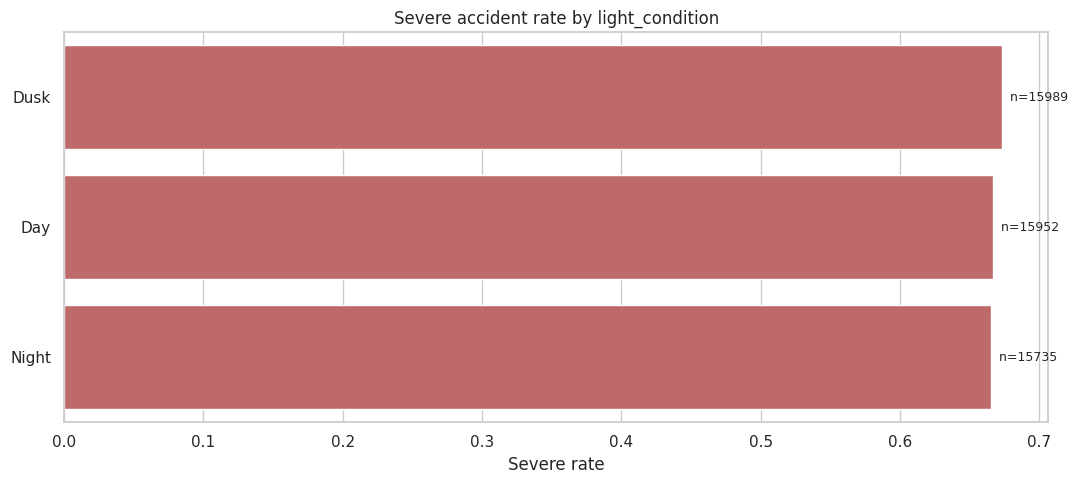

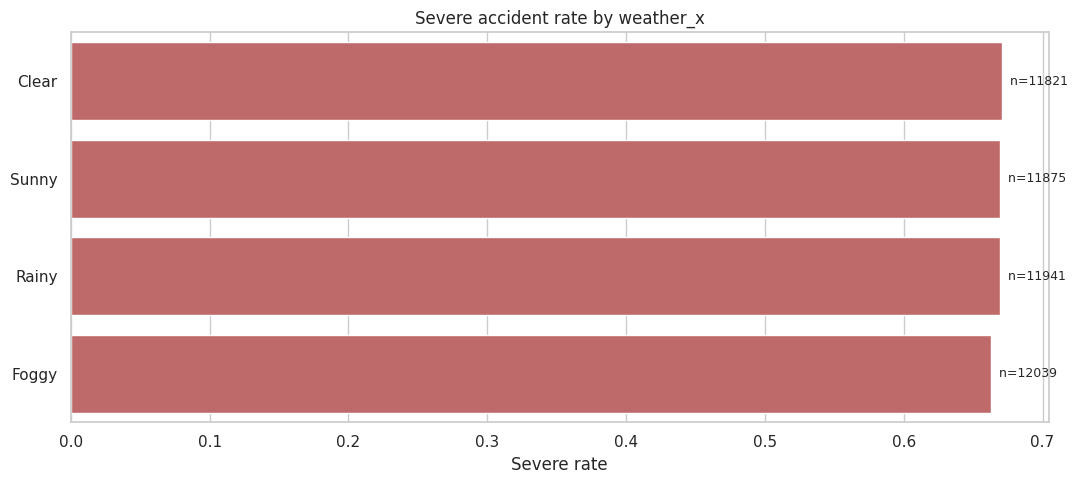

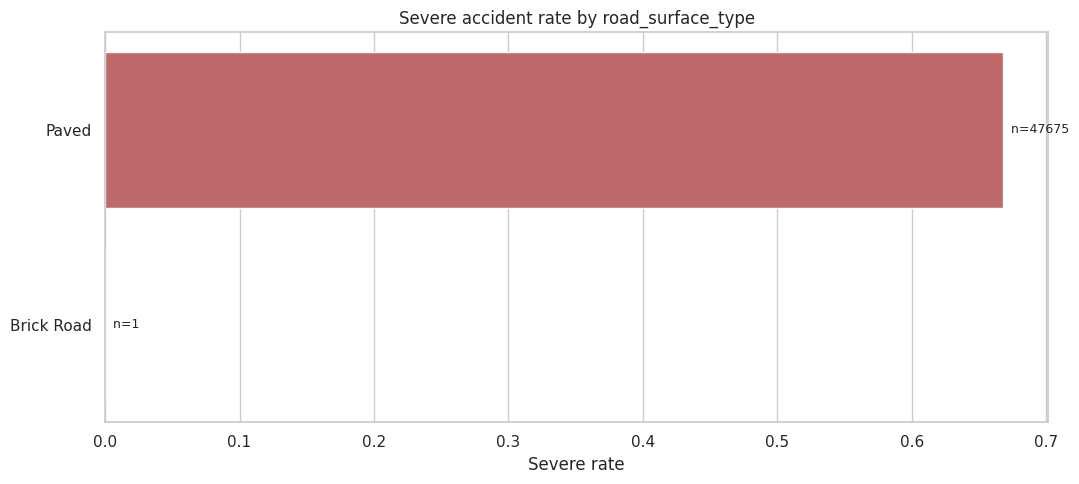

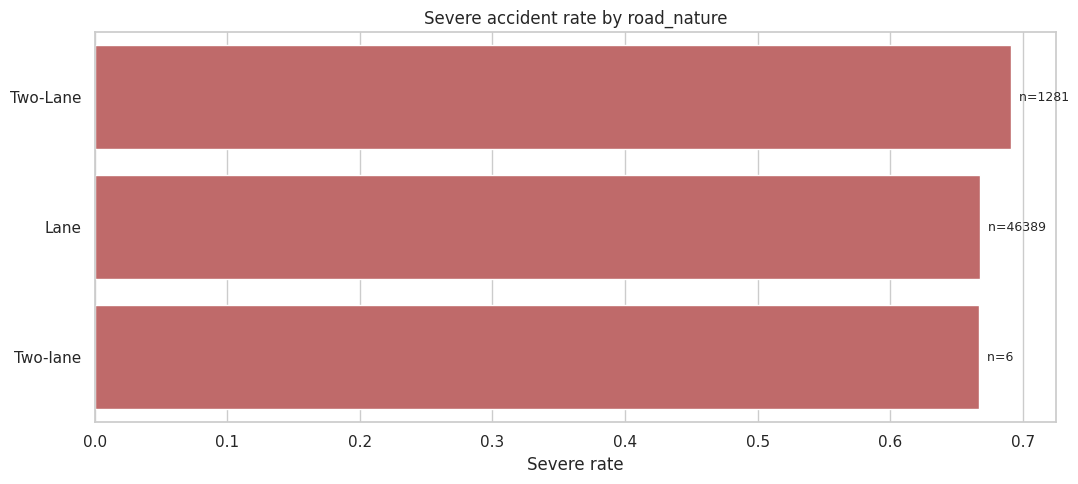

In [15]:
leak_pattern = "kill|death|dead|fatal|injur|casualt|victim|severe|severity"
identifier_pattern = r"(?:^|_)(?:id|serial|sl|no|index)(?:$|_)"
skip_columns = {date_col, time_col}

categorical_cols = [
    column for column in df.columns
    if not is_numeric(df[column])
    and column not in skip_columns
    and 2 <= df[column].nunique() <= 30
    and df[column].isna().mean() < 0.4
    and not pd.Series(column).str.contains(leak_pattern).iloc[0]
    and not pd.Series(column).str.contains(identifier_pattern).iloc[0]
]

profile_cols = [column for column in categorical_cols if column not in engineered + [division_col, district_col]][:4]
print("Condition columns profiled:", profile_cols)

for column in profile_cols:
    summary = df.groupby(column)["severe"].agg(["size", "mean"]).sort_values("size", ascending=False).head(10)
    summary = summary.sort_values("mean", ascending=False)
    ax = sns.barplot(x=summary["mean"], y=summary.index, color="indianred")
    for position, (rate, size) in enumerate(zip(summary["mean"], summary["size"])):
        ax.text(rate, position, f"  n={size}", va="center", fontsize=9)
    ax.set_title(f"Severe accident rate by {column}")
    ax.set_xlabel("Severe rate")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 11. Statistical evidence: which factors really matter?

A pattern in a chart can be pure chance. For every factor, a chi-square test checks whether severity differs between its categories more than chance would explain, and **Cramér's V** measures how strong the link is.

| Cramér's V | Strength of the link |
|---|---|
| below 0.05 | negligible |
| 0.05 to 0.10 | weak |
| 0.10 to 0.20 | moderate |
| above 0.20 | strong |

With thousands of records, even tiny differences become statistically significant, so the effect size (V) matters more than the p-value.

In [16]:
association_columns = categorical_cols + [column for column in ["year", "month", "hour"] if column in df.columns]

rows = []
for column in association_columns:
    table = pd.crosstab(df[column], df["severe"])
    if table.shape[0] > 1 and table.shape[1] > 1:
        chi2, p_value, _, _ = chi2_contingency(table)
        cramers_v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
        rows.append({"factor": column, "categories": table.shape[0], "cramers_v": cramers_v,
                     "p_value": p_value, "significant": p_value < 0.05})

association = pd.DataFrame(rows, columns=["factor", "categories", "cramers_v", "p_value", "significant"])
association = association.sort_values("cramers_v", ascending=False).reset_index(drop=True)
association.round(4)

,factor,categories,cramers_v,p_value,significant
0,hour,24,0.0257,0.1171,False
1,trafic_condition,25,0.0201,0.7410,False
2,month,12,0.0159,0.3639,False
3,month,12,0.0159,0.3639,False
4,junction,9,0.0145,0.2678,False
5,type_of_road_connection_point,7,0.0134,0.1977,False
6,road_classification,4,0.0126,0.0559,False
7,lighting,4,0.0117,0.0874,False
8,year,15,0.0114,0.9612,False
9,traffic_control,6,0.0110,0.3304,False


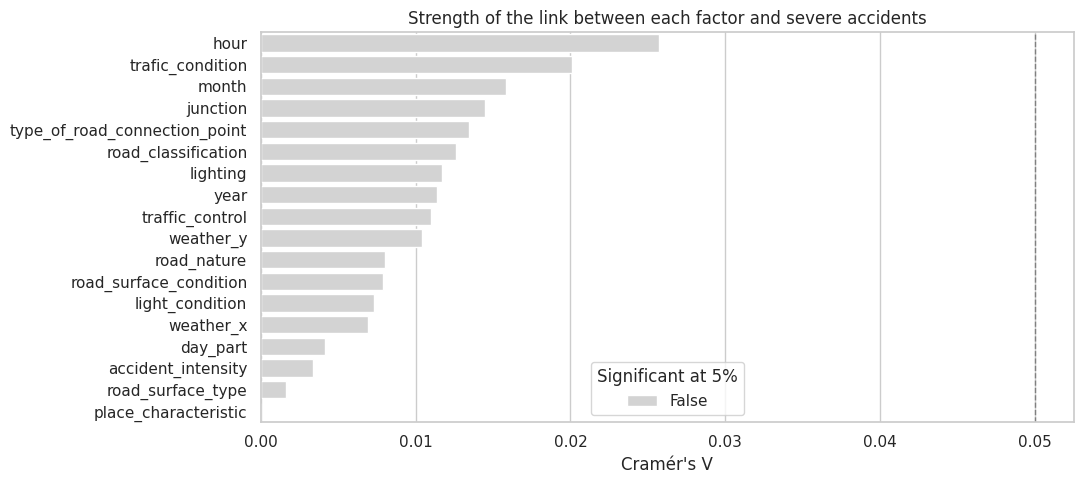

In [17]:
if not association.empty:
    sns.barplot(data=association, x="cramers_v", y="factor", hue="significant",
                palette={True: "teal", False: "lightgrey"})
    plt.axvline(0.05, color="grey", linestyle="--", linewidth=1)
    plt.title("Strength of the link between each factor and severe accidents")
    plt.xlabel("Cramér's V")
    plt.ylabel("")
    plt.legend(title="Significant at 5%")
    plt.tight_layout()
    plt.show()

## 12. Key findings

In [18]:
findings = []

if not yearly.empty:
    peak = yearly.loc[yearly["casualties"].idxmax()]
    findings.append(
        f"Casualties peaked in {int(peak['year'])} with "
        f"{int(peak['casualties']):,} people killed or injured."
    )

if "month" in df.columns:
    by_month = df.groupby("month").agg(
        accidents=("severe", "size"),
        rate=("severe", "mean")
    )

    most_accidents_month = by_month["accidents"].idxmax()
    highest_severity_month = by_month["rate"].idxmax()

    findings.append(
        f"Month {most_accidents_month} has the most accidents, while month "
        f"{highest_severity_month} has the highest share of severe ones "
        f"({by_month['rate'].max():.1%})."
    )

if "season" in df.columns:
    by_season = df.groupby("season")["severe"].mean()

    findings.append(
        f"{by_season.idxmax()} is the most dangerous season by severity "
        f"({by_season.max():.1%} severe)."
    )

if "day_part" in df.columns:
    by_part = df.groupby("day_part")["severe"].mean()

    findings.append(
        f"{by_part.idxmax()} accidents are the most likely to be severe "
        f"({by_part.max():.1%}), compared with "
        f"{by_part.min():.1%} during {by_part.idxmin()}."
    )

if "weekday" in df.columns:
    by_day = df.groupby("weekday").size()

    findings.append(
        f"{by_day.idxmax()} records the highest number of accidents "
        f"({by_day.max():,})."
    )

for geo_col in geo_columns:
    by_geo = df.groupby(geo_col)["total_casualties"].sum()

    findings.append(
        f"{by_geo.idxmax()} is the {geo_col} with the most casualties "
        f"({int(by_geo.max()):,})."
    )

if not risk.empty:
    critical_names = (
        risk[risk["risk_tier"] == "Critical"]
        .index.astype(str)
        .tolist()
    )

    if critical_names:
        findings.append(
            f"Critical risk tier ({risk_col}): "
            + ", ".join(critical_names[:5]) + "."
        )
    else:
        top_name = risk.index[0]
        findings.append(
            f"{top_name} has the highest risk score among "
            f"{risk_col} values, with no location in the Critical tier."
        )

if not association.empty:
    leader = association.iloc[0]

    findings.append(
        f"'{leader['factor']}' has the strongest link with severity "
        f"(Cramér's V = {leader['cramers_v']:.3f})."
    )

    meaningful = association[association["cramers_v"] >= 0.05]

    if meaningful.empty:
        findings.append(
            "No single factor has a link stronger than negligible, "
            "so severity depends on circumstances not recorded in this dataset."
        )

for number, finding in enumerate(findings, start=1):
    print(f"{number}. {finding}")

1. Casualties peaked in 2021 with 15,000 people killed or injured.
2. Month September has the most accidents, while month May has the highest share of severe ones (68.5%).
3. Morning accidents are the most likely to be severe (69.0%), compared with 66.8% during Evening.
4. 'hour' has the strongest link with severity (Cramér's V = 0.026).
5. No single factor has a link stronger than negligible, so severity depends on circumstances not recorded in this dataset.
